1. Include the data set and preprocessing for following machine learning.

In [1]:
## import libs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
# from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

##include minist dataset
mnist = fetch_openml('mnist_784', version=1)
print(mnist.keys())
X_t, y_t = mnist["data"], mnist["target"]
## decrese the size of dataset for faster computation
X,_,y,_ =train_test_split(X_t, y_t, train_size=7000, stratify=y_t, random_state=0)

print(X.shape)
print(y.shape)

##Preprocessing
#alignment
X = X.to_numpy()
X = X.astype(np.float32)
y = y.astype(np.int64)
y = y.to_numpy()
#normalization
X = X / 255.0
# print(X[0])
# print(y[0])

##Split the data set into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=0)
print("Training Feature Dimension:",X_train.shape)
print("Traing Label Dimension:",y_train.shape)
print("Testing Feature Dimension:",X_test.shape)
print("Testing Label Dimension:",y_test.shape)

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(7000, 784)
(7000,)
Training Feature Dimension: (6000, 784)
Traing Label Dimension: (6000,)
Testing Feature Dimension: (1000, 784)
Testing Label Dimension: (1000,)


2. Classifier Models Set up

In [13]:
## Minimum Euclidean Distance Classifier
class MED:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.means = []
        self.classes = np.unique(y)
        for w in self.classes:
            X_w = X[y == w]
            mean_w = np.mean(X_w, axis=0)
            self.means.append(mean_w)
        self.means = np.array(self.means)

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.means, axis=2)
        return self.classes[np.argmin(distances, axis=1)]
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
## Mnimun Mahalanobis Distance Classifier
class MMD:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.covariance = np.cov(X, rowvar=False) + 1e-6 * np.eye(X.shape[1])  
        self.inv_covariance = np.linalg.inv(self.covariance)
        self.means = []
        for w in self.classes:
            X_w = X[y == w]
            mean_w = np.mean(X_w, axis=0)
            self.means.append(mean_w)
        self.means = np.array(self.means)

    def predict(self, X):
        diff = X[:, np.newaxis] - self.means
        distances = np.einsum('ijk,kl,ijl->ij', diff, self.inv_covariance, diff)
        return self.classes[np.argmin(distances, axis=1)]
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
## Bayes Classifier
class Bayes:
    def __init__(self):
        pass

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = []
        self.means = []
        self.covariances = []
        for w in self.classes:
            X_w = X[y == w]
            prior_w = X_w.shape[0] / X.shape[0]
            mean_w = np.mean(X_w, axis=0)
            cov_w = np.cov(X_w, rowvar=False) + 1e-6 * np.eye(X.shape[1])  
            self.priors.append(prior_w)
            self.means.append(mean_w)
            self.covariances.append(cov_w)
        self.priors = np.array(self.priors)
        self.means = np.array(self.means)
        self.covariances = np.array(self.covariances)

    def predict(self, X):
        log_likelihoods = []
        for w in range(len(self.classes)):
            mean_w = self.means[w] 
            cov_w = self.covariances[w]
            inv_cov_w = np.linalg.inv(cov_w)
            det_cov_w = np.linalg.det(cov_w)
            diff = X - mean_w
            log_likelihood_w = -0.5 * np.sum(diff @ inv_cov_w * diff, axis=1) - 0.5 * np.log(det_cov_w) + np.log(self.priors[w])
            log_likelihoods.append(log_likelihood_w)
        log_likelihoods = np.array(log_likelihoods).T
        return self.classes[np.argmax(log_likelihoods, axis=1)]
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
## Linear Regression Classifier

## kNN Classifier
class kNN():
    def __init__(self,k):
        self.k=k

    def fit(self,X,y):
        self.classes=np.unique(y)
        self.data=X
        self.d_label=y
        
    
    def Distance(self,d,t):
        return np.sum((d-t)*(d-t))
    
    def predict(self,X_test):
        y_pred=[]
        for x in X_test:
            dists=[]
            for data in self.data:
                dists.append(self.Distance(data,x))
            dists=np.array(dists)
            idk=np.argpartition(dists,self.k)[0:self.k]
            klabels=self.d_label[idk]
            labels, counts=np.unique(klabels,return_counts=True)
            y_pred.append(labels[np.argmax(counts)])
        y_pred=np.array(y_pred)
        return y_pred

    def score(self,X_test,y_test):
        y_pred=self.predict(X_test)
        accuracy=np.mean(y_pred == y_test)
        return accuracy



        







3. Evaluate Classification

In [14]:
classifier_med=MED()
classifier_med.fit(X_train, y_train)
y_pred_med=classifier_med.predict(X_test)   
accuracy_med=classifier_med.score(X_test,y_test)
print("MED accuracy:", accuracy_med)

# classifier_bayes=Bayes()
# classifier_bayes.fit(X_train, y_train)
# y_pred_bayes=classifier_bayes.predict(X_test)
# accuracy_bayes=classifier_bayes.score(X_test,y_test)
# print("Bayes accuracy:", accuracy_bayes)

classifier_mmd=MMD()
classifier_mmd.fit(X_train, y_train)
y_pred_mmd=classifier_mmd.predict(X_test)
accuracy_mmd=classifier_mmd.score(X_test,y_test)
print("MMD accuracy:", accuracy_mmd)

classifier_knn=kNN(k=3)
classifier_knn.fit(X_train,y_train)
y_pred_knn=classifier_knn.predict(X_test)
accuracy_knn=classifier_knn.score(X_test,y_test)
print("kNN accuracy:", accuracy_knn)

classifier_lr=LogisticRegression(max_iter=1000)
classifier_lr.fit(X_train, y_train)
y_pred_lr=classifier_lr.predict(X_test)
accuracy_lr=classifier_lr.score(X_test,y_test)
print("Logistic Regression accuracy:", accuracy_lr)

MED accuracy: 0.812
MMD accuracy: 0.822
kNN accuracy: 0.935
Logistic Regression accuracy: 0.894


4. Dimension Reduction

In [ ]:
## PCA for Dimension Reduction
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        covariance_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components = eigenvectors[:, sorted_indices[:self.n_components]]

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

## LDA for Dimension Reduction
from scipy.linalg import eigh  

class LDA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.scalings = None
        self.overall_mean = None
        self.classes = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        self.overall_mean = X.mean(axis=0)
        means = np.array([X[y == c].mean(axis=0) for c in self.classes])
        Sw = np.zeros((n_features, n_features))
        for i, c in enumerate(self.classes):
            Xc = X[y == c] - means[i]
            Sw += Xc.T @ Xc
        Sw += 1e-6 * np.eye(n_features) #invertable
        Sb = np.zeros((n_features, n_features))
        for i, c in enumerate(self.classes):
            n_c = (y == c).sum()
            mean_diff = (means[i] - self.overall_mean).reshape(-1, 1)
            Sb += n_c * (mean_diff @ mean_diff.T)
        eigvals, eigvecs = eigh(Sb, Sw)
        sorted_idx = np.argsort(eigvals)[::-1]
        max_comp = min(len(self.classes) - 1, n_features)
        n_comp = max_comp if self.n_components is None else min(self.n_components, max_comp)
        self.scalings = eigvecs[:, sorted_idx[:n_comp]]
        return self

    def transform(self, X):
        if self.scalings is None:
            raise RuntimeError("Call fit first.")
        X = np.asarray(X, dtype=float)
        Xc = X - self.overall_mean
        return Xc @ self.scalings

5. Evaluate and Visualize

In [18]:
#import lda
def model_accuracy(dimensions, X_train, y_train, X_test, y_test, model, method):
    accuracys=[]
    for dim in dimensions:
        # reduction method selection
        if method == 'PCA':
            reduction_m = PCA(n_components=dim)
            reduction_m.fit(X_train)
            X_train_reduced = reduction_m.transform(X_train)
            X_test_reduced = reduction_m.transform(X_test)
        elif method == 'LDA':
            reduction_m = LDA(n_components=min(dim, len(np.unique(y_train))-1))
            reduction_m.fit(X_train,y_train)
            X_train_reduced = reduction_m.transform(X_train)
            X_test_reduced = reduction_m.transform(X_test)  
        elif method == 'Fisher' :
            pca_dim = max(dim // 2, 1)
            lda_dim = max(dim - pca_dim, 1)
            pca = PCA(n_components=pca_dim)
            pca.fit(X_train)
            X_train_pca = pca.transform(X_train)
            X_test_pca = pca.transform(X_test)

            lda = LDA(n_components=min(lda_dim, len(np.unique(y_train)) - 1))
            lda.fit(X_train_pca, y_train)
            X_train_reduced = lda.transform(X_train_pca)
            X_test_reduced = lda.transform(X_test_pca)
        else:
            raise ValueError("Unknown method")
        # classification model selection
        if model == 'MED':
            classifier = MED()
        elif model == 'MMD':
            classifier = MMD()
        elif model == 'kNN':
            classifier = kNN(3)
        elif model == 'LogisticRegression':
            classifier = LogisticRegression(max_iter=1000)
        else:
            raise ValueError("Unknown model")
        # evaluation
        classifier.fit(X_train_reduced, y_train)
        accuracy = classifier.score(X_test_reduced, y_test)
        accuracys.append(accuracy)
    return np.array(accuracys)

def arrangement(dimensions, X_train, y_train, X_test, y_test, models, methods):
    accuracys_all=[]
    refer_acc=[]
    for model in models:
        accuracys_model=[]
        if model == 'MED':
            classifier = MED()
        elif model == 'MMD':
            classifier = MMD()
        elif model == 'kNN':
            classifier = kNN(3)
        elif model == 'LogisticRegression':
            classifier = LogisticRegression(max_iter=1000)
        else:
            raise ValueError("Unknown model")
        classifier.fit(X_train, y_train)
        accuracy_origin = classifier.score(X_test, y_test)
        refer_acc.append(accuracy_origin)
        for method in methods:
            accuracys_method=model_accuracy(dimensions, X_train, y_train, X_test, y_test, model, method)
            accuracys_model.append(accuracys_method)
        accuracys_all.append(accuracys_model)
    return np.array(accuracys_all), np.array(refer_acc)

def visualize(dimensions,accuracys,models,methods,refer_acc):
    for i, model in enumerate(models):
        x=dimensions
        y=accuracys[i]
        plt.figure()
        for j, method in enumerate(methods):
            plt.plot(x,y[j], label=method)
        origin_acc=np.zeros(x.shape)+refer_acc[i]
        plt.plot(x,origin_acc, label='Original Accuracy', linestyle='--', color='red')
        plt.title(f'Accuracy vs Number of Dimensions for {model}') 
        plt.xscale('log')              
        plt.xticks(dimensions, dimensions) 
        plt.xlabel('Number of Dimensions')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid()
        plt.savefig(f'Report/Images/{model}_accuracy.png')
        plt.show()
        

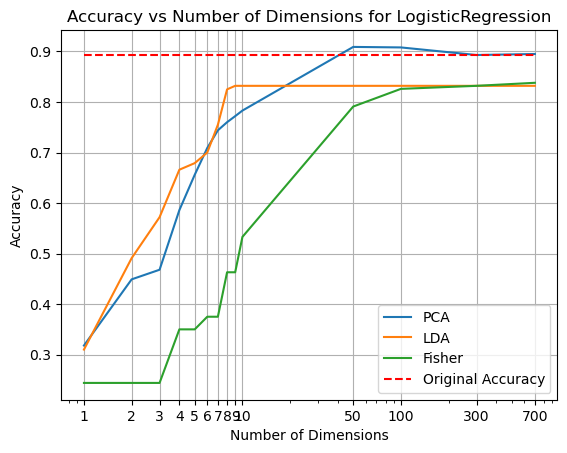

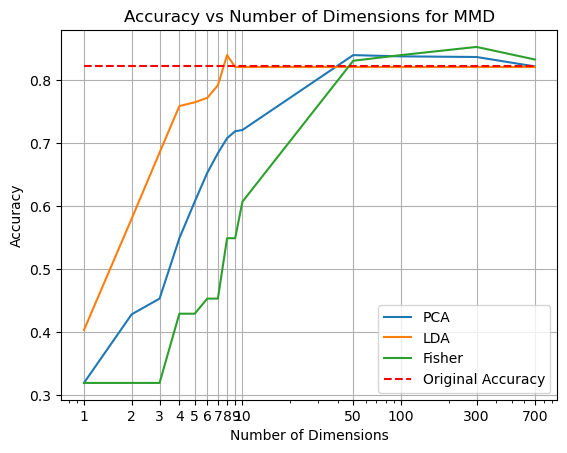

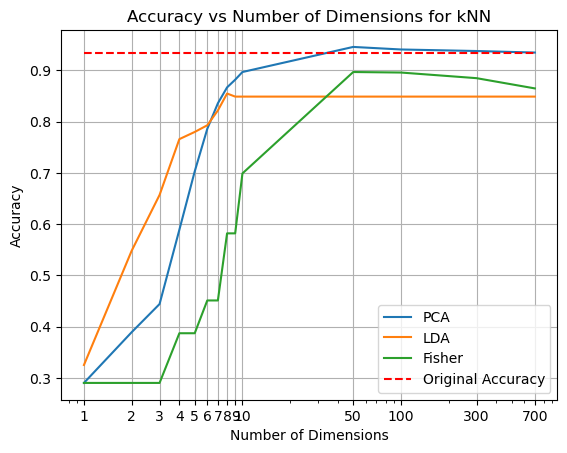

In [19]:
dimensions = np.array([1,2,3,4,5,6,7,8,9,10,50,100,300,700])
models=[ 'LogisticRegression','MMD','kNN']
methods = ['PCA', 'LDA', 'Fisher']
accuracys_total, refer_acc=arrangement(dimensions, X_train, y_train, X_test, y_test, models, methods)
# print(accuracys_total)  
visualize(dimensions,accuracys_total,models,methods,refer_acc)

6. Add Manifold Learning to reduce dimension

In [20]:
## Isomap for Dimension Reduction
from sklearn.manifold import Isomap
dimensions=np.array([1,2,3,4,5,6,7,8,9,10,50,100,300,700])
accuracys_isomap=[]
for n in dimensions:
    reduction_m = Isomap(n_components=n)
    reduction_m.fit(X_train)
    X_train_reduced = reduction_m.transform(X_train)
    X_test_reduced = reduction_m.transform(X_test)
    classifier_lr=LogisticRegression(max_iter=1000)
    classifier_lr.fit(X_train_reduced, y_train)
    y_pred_lr=classifier_lr.predict(X_test_reduced)
    accuracy_lr=classifier_lr.score(X_test_reduced,y_test)
    accuracys_isomap.append(accuracy_lr)

In [21]:
## LLE for Dimension Reduction
from sklearn.manifold import LocallyLinearEmbedding
accuracys_lle=[]
for n in dimensions:
    reduction_m = LocallyLinearEmbedding(n_components=n)
    reduction_m.fit(X_train)
    X_train_reduced = reduction_m.transform(X_train)
    X_test_reduced = reduction_m.transform(X_test)
    classifier_lr=LogisticRegression(max_iter=1000)
    classifier_lr.fit(X_train_reduced, y_train)
    y_pred_lr=classifier_lr.predict(X_test_reduced)
    accuracy_lr=classifier_lr.score(X_test_reduced,y_test)
    accuracys_lle.append(accuracy_lr)

In [22]:
## use pacmap for Dimension Reduction
import pacmap
accracys=[]
for n in dimensions:
    embedding = pacmap.PaCMAP(
        n_components=n, 
        n_neighbors=10, 
        MN_ratio=0.5, 
        FP_ratio=2.0
    )
    X_reduced=embedding.fit_transform(X)
    X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(X_reduced, y, test_size=1/7, random_state=0)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_reduced, y_train)
    accuracy = clf.score(X_test_reduced, y_test)
    accracys.append(accuracy)
accuracys=np.array(accracys)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.


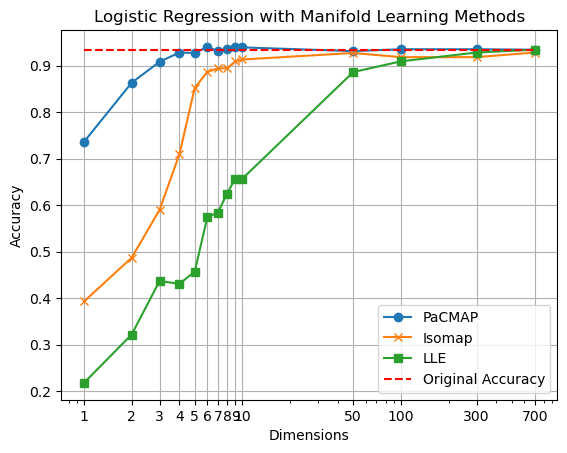

In [23]:
plt.figure()
plt.plot(dimensions, accuracys, label='PaCMAP', marker='o')
plt.plot(dimensions, accuracys_isomap, label='Isomap', marker='x')
plt.plot(dimensions, accuracys_lle, label='LLE', marker='s')
plt.plot(dimensions, np.zeros(dimensions.shape)+accuracy_lr, label='Original Accuracy', linestyle='--', color='red')
plt.xscale('log')              
plt.xticks(dimensions, dimensions)
plt.legend()
plt.grid()
plt.title('Logistic Regression with Manifold Learning Methods')
plt.xlabel('Dimensions')
plt.ylabel('Accuracy')
##save figure to Report/Images
plt.savefig('Report/Images/manifold_methods_accuracy.png')
plt.show()